In [1]:
import pandas as pd

# Créditos del dataframe: https://www.kaggle.com/shivamsahu0

df = pd.read_csv('C:/Users/becem/Desktop/Entorno_VS_Jupiterlab/Datasets/Coffe_sales.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   str    
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   str    
 4   Time_of_Day  3547 non-null   str    
 5   Weekday      3547 non-null   str    
 6   Month_name   3547 non-null   str    
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   str    
 10  Time         3547 non-null   str    
dtypes: float64(1), int64(3), str(7)
memory usage: 304.9 KB


Visualizo info para ver el tipo de datos y estructura general. Veo que esta depurado de datos nulos, voy a revisar más adelante duplicados y demás.

Este data set me interesa porque estoy aprendiendo a trabajar con fechas y horas, en la siguiente celda voy a visualizar la columna Time_of_day y ver si es hora o simplemente indica el momento del día.

In [2]:
# Visualizo unas pocas filas de Time_of_Day

df['Time_of_Day'].head(5)

0      Morning
1    Afternoon
2    Afternoon
3    Afternoon
4    Afternoon
Name: Time_of_Day, dtype: str

Interesante... No me sirve para practicar, revisaré time

In [3]:
# Visualizo unas pocas filas de Time

df['Time'].head(5)

0    10:15:50.520000
1    12:19:22.539000
2    12:20:18.089000
3    13:46:33.006000
4    13:48:14.626000
Name: Time, dtype: str

Genial, una hora formateada en str-object, me servirá para practicar. format = '%H:%m:%s'

In [4]:
# al principio intente format='%H:%M:%S.%f', pero me daba error, resulta que no todos los valores de time tenian flotantes
# format = 'mixed' tiene en cuenta esto

df['Time'] = pd.to_datetime(df['Time'], format='mixed').dt.time
df['Time'].head(5)

0    10:15:50.520000
1    12:19:22.539000
2    12:20:18.089000
3    13:46:33.006000
4    13:48:14.626000
Name: Time, dtype: object

Ha creado un object pero me interesa hacer calculos con la hora encontre que pd.to_timedelta() cambía el tipo de dato a un valor con el que se pueden hacer cálculos

In [5]:
# Para poder usar la funcion pd.to_timedelta es necesario que el dato sea str
df['Time'] = df['Time'].astype(str)
df['Time'] = pd.to_timedelta(df['Time'])
df['Time'].info()

<class 'pandas.Series'>
RangeIndex: 3547 entries, 0 to 3546
Series name: Time
Non-Null Count  Dtype          
--------------  -----          
3547 non-null   timedelta64[us]
dtypes: timedelta64[us](1)
memory usage: 27.8 KB


Verificado que el tipo de dato ha cambiado a timedelta64[us] ahora puedo hacer cálculos

In [6]:
# Visualizo las fechas con sample para descubrir el formato
# Me interesa saber cual es el mes para dar formato adecuado

df['Date'].sample(5)

1434    2024-09-10
2808    2025-02-01
249     2024-04-16
905     2024-07-19
3043    2025-02-17
Name: Date, dtype: str

Vale, es un dato de fecha parece que tiene el siguiente format = '%Y-%m-%d'

In [7]:
# Voy a extraer los días de la columna Date

# utilizo 
df['Date'] = pd.to_datetime(df['Date'], format = '%Y-%m-%d')

df['Day'] = df['Date'].dt.day

print(df[['Date','Day']].sample(10))
print(df['Date'].info)

           Date  Day
1974 2024-10-23   23
1062 2024-08-03    3
1871 2024-10-16   16
257  2024-04-17   17
1407 2024-09-08    8
2490 2024-12-19   19
3120 2025-02-21   21
47   2024-03-08    8
785  2024-06-26   26
3140 2025-02-24   24
<bound method Series.info of 0      2024-03-01
1      2024-03-01
2      2024-03-01
3      2024-03-01
4      2024-03-01
          ...    
3542   2025-03-23
3543   2025-03-23
3544   2025-03-23
3545   2025-03-23
3546   2025-03-23
Name: Date, Length: 3547, dtype: datetime64[us]>


Compruebo que ha cambiado a datetime64

In [8]:
# Puedo extraer tambíen el nombre mes

# utilizo la funcion day_month en la llamada del pd
df['Date'] = pd.to_datetime(df['Date'], format = '%Y-%m-%d')

df['Month'] = df['Date'].dt.month_name()

print(df[['Date','Month']].sample(10))

           Date      Month
940  2024-07-24       July
21   2024-03-03      March
1084 2024-08-05     August
2440 2024-12-12   December
239  2024-04-14      April
2660 2025-01-11    January
2451 2024-12-14   December
1822 2024-10-13    October
1677 2024-10-02    October
1444 2024-09-11  September


Aunque en el df original ya hay una columna con el nombre del mes queria probar esta función

In [9]:
# Voy a extraer los nombres de los días de la semana de columna Date

# utilizo la funcion day_name en la llamada del pd
df['Date'] = pd.to_datetime(df['Date'], format = '%Y-%m-%d')

df['Day_name'] = df['Date'].dt.day_name()

print(df[['Date','Day_name']].sample(10))

           Date   Day_name
1822 2024-10-13     Sunday
2970 2025-02-12  Wednesday
2301 2024-11-23   Saturday
147  2024-03-26    Tuesday
1760 2024-10-09  Wednesday
2284 2024-11-21   Thursday
519  2024-05-26     Sunday
1070 2024-08-03   Saturday
3514 2025-03-21     Friday
1773 2024-10-10   Thursday


In [10]:
df['Month_name'].sample(5)

1794    Oct
1650    Sep
499     May
2521    Dec
249     Apr
Name: Month_name, dtype: str

Los nombres de los meses en el dataframe original están acortados, voy a borrar esa columna porque no me interesa

In [11]:
# No encuentro utilidad a las siguientes columnas las elimino, porque ó son int ó el nombre está acortado
# Cierto que Day la cree yo pero no le veo uso, añadiré cualquiera que necesite más adelante con las funciones de pd.to_time()
df = df.drop('Day', axis=1)
df = df.drop('Weekday', axis=1)
df = df.drop('Weekdaysort', axis=1)
df = df.drop('Monthsort', axis=1)
df = df.drop('Month_name', axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   hour_of_day  3547 non-null   int64          
 1   cash_type    3547 non-null   str            
 2   money        3547 non-null   float64        
 3   coffee_name  3547 non-null   str            
 4   Time_of_Day  3547 non-null   str            
 5   Date         3547 non-null   datetime64[us] 
 6   Time         3547 non-null   timedelta64[us]
 7   Month        3547 non-null   str            
 8   Day_name     3547 non-null   str            
dtypes: datetime64[us](1), float64(1), int64(1), str(5), timedelta64[us](1)
memory usage: 249.5 KB


In [12]:
#df['date'] = pd.to_datetime(df['date'])
print(df['Date'].head())
print(df['Time'].head())

0   2024-03-01
1   2024-03-01
2   2024-03-01
3   2024-03-01
4   2024-03-01
Name: Date, dtype: datetime64[us]
0   0 days 10:15:50.520000
1   0 days 12:19:22.539000
2   0 days 12:20:18.089000
3   0 days 13:46:33.006000
4   0 days 13:48:14.626000
Name: Time, dtype: timedelta64[us]


Visualizo Date y Time y compruebo que el tipo de dato es el que necesito

In [13]:
# Creo una lista con los meses ordenados
orden_meses = ['January','February','March','April','May','June','July','August','September','October','November','December']
# Agrupo según los meses y que refleje la media de gasto en money
gasto_medio_mes = df.groupby('Month')['money'].mean().reindex(orden_meses)
print(gasto_medio_mes)

Month
January      31.835124
February     31.242270
March        32.169312
April        34.045000
May          33.877261
June         34.160359
July         29.181181
August       27.992059
September    29.036744
October      32.608357
November     33.168108
December     31.805946
Name: money, dtype: float64


Se podría hacer una tabla sencilla para ver los gastos por mes

In [14]:
# Creo una lista con los meses ordenados
orden_meses = ['January','February','March','April','May','June','July','August','September','October','November','December']
# Creo una función para aplicar en agg
def mas_frecuente(serie):
    # En caso de empate mostraría el primero
    return serie.mode().iloc[0]
# Agrupo según los meses y que reflejen la media de gasto en money
cafe_mas_comun_mes = df.groupby('Month')['coffee_name'].agg(mas_frecuente).reindex(orden_meses)
# Con reindex() indico el orden en que los meses tienen que aparecer, me resultará util para cuando haga tablas de visualización
print(cafe_mas_comun_mes)

Month
January      Americano with Milk
February               Americano
March                  Americano
April        Americano with Milk
May          Americano with Milk
June         Americano with Milk
July         Americano with Milk
August       Americano with Milk
September    Americano with Milk
October                    Latte
November                   Latte
December     Americano with Milk
Name: coffee_name, dtype: str


Está claro que el favorito de los clientes es el Americano with Milk

In [15]:
cafe_mas_comun_mes.agg(mas_frecuente)

'Americano with Milk'

Lo muestro con ayuda de la función mas_frecuente...

In [16]:
# Creo una lista con los meses ordenados
orden_meses = ['January','February','March','April','May','June','July','August','September','October','November','December']
# Creo una función para aplicar en agg
def modas(serie):
    # Muestra la moda para los dos principales cafes en el caso de que haya empate
    return ", ".join(serie.mode())
# Agrupo según los meses y que refleje la media de gasto en money
cafes_mas_comunes_mes = df.groupby('Month')['coffee_name'].agg(modas).reindex(orden_meses)
print(cafes_mas_comunes_mes)
# En este caso no parece que haya 'empates'

Month
January      Americano with Milk
February               Americano
March                  Americano
April        Americano with Milk
May          Americano with Milk
June         Americano with Milk
July         Americano with Milk
August       Americano with Milk
September    Americano with Milk
October                    Latte
November                   Latte
December     Americano with Milk
Name: coffee_name, dtype: str


Lo de arriba es una alternativa a más frecuente para mostrar la moda de los más frecuentes en caso de que en el conteo hubiera empate.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   hour_of_day  3547 non-null   int64          
 1   cash_type    3547 non-null   str            
 2   money        3547 non-null   float64        
 3   coffee_name  3547 non-null   str            
 4   Time_of_Day  3547 non-null   str            
 5   Date         3547 non-null   datetime64[us] 
 6   Time         3547 non-null   timedelta64[us]
 7   Month        3547 non-null   str            
 8   Day_name     3547 non-null   str            
dtypes: datetime64[us](1), float64(1), int64(1), str(5), timedelta64[us](1)
memory usage: 249.5 KB


In [18]:
# Me interesa saber cual es el cafe favorito según la hora del dia
cafe_segun_hora = df.groupby('hour_of_day')['coffee_name'].agg(modas)
print(cafe_segun_hora)

hour_of_day
6     Americano, Americano with Milk
7                              Latte
8                Americano with Milk
9                Americano with Milk
10               Americano with Milk
11                         Americano
12    Americano, Americano with Milk
13               Americano with Milk
14                             Latte
15                             Latte
16                             Latte
17               Americano with Milk
18                             Latte
19                             Latte
20                             Latte
21                             Latte
22                             Latte
Name: coffee_name, dtype: str


In [19]:
# Cambio el tipo de dato de hour_of_day de str a int para poder hacer comparaciones numéricas
df['hour_of_day'] = df['hour_of_day'].astype(int)
# Defino una función con argumentos int, las muestras contienen el rango de 6 a 22 horas
def cafe_por_rango_hora(hora_1,hora_2):
    # Filtro el rango de horas, en el comentario de abajo el clásico confiable
    # filtro = df[(df['hour_of_day'] >= hora_1) & (df['hour_of_day'] <= hora_2)]
    # Aquí con query porque está de moda...
    filtro = df.query("hour_of_day >= @hora_1 and hour_of_day <= @hora_2")
    # Primero agrupo hour_of_day con coffe_name y aplico la funcion mas_frecuente
    resultado_rango = filtro.groupby('hour_of_day')['coffee_name'].agg(mas_frecuente)
    # Luego vuelvo a aplicar mas_frecuente para el resultado_rango
    resultado = resultado_rango.agg(mas_frecuente)
    return resultado
print("......Buscando cafés favoritos para los rangos de hora solicitados......")
print()
print(f'Favorito para el desayuno : Café {cafe_por_rango_hora(6,8).lower()}')
print()
print(f'Favorito para el almuerzo : Café {cafe_por_rango_hora(10,12).lower()}.')
print()
print(f'Favorito para la comida : Café {cafe_por_rango_hora(13,15).lower()}.')
print()
print(f'Favorito para la noche : Café {cafe_por_rango_hora(20,22).lower()}.')

......Buscando cafés favoritos para los rangos de hora solicitados......

Favorito para el desayuno : Café americano

Favorito para el almuerzo : Café americano.

Favorito para la comida : Café latte.

Favorito para la noche : Café latte.


In [20]:
# Defino una función con argumentos int, las muestras contienen el rango de 6 a 22 horas
def gasto_medio_por_rango_hora(hora_1,hora_2):
    # Filtro el rango de horas, en el comentario de abajo el clásico confiable
    filtro = df[(df['hour_of_day'] >= hora_1) & (df['hour_of_day'] <= hora_2)]
    # Aquí con query porque está de moda...
    # filtro = df.query("hour_of_day >= @hora_1 and hour_of_day <= @hora_2")
    # Primero agrupo hour_of_day con coffe_name y aplico la funcion mas_frecuente
    resultado_rango = filtro.groupby('hour_of_day')['money'].mean()
    resultado = resultado_rango.mean()
    return resultado
print("......Calculando gasto medio para los rangos de hora solicitados......")
print()
print(f'Gasto medio para el desayuno : {gasto_medio_por_rango_hora(6,8).round(2)} denarios')
print()
print(f'Gasto medio para el almuerzo : {gasto_medio_por_rango_hora(10,12).round(2)} denarios')
print()
print(f'Gasto medio para la comida : {gasto_medio_por_rango_hora(13,15).round(2)} denarios')
print()
print(f'Gasto medio para la noche : {gasto_medio_por_rango_hora(20,22).round(2)} denarios')

......Calculando gasto medio para los rangos de hora solicitados......

Gasto medio para el desayuno : 30.69 denarios

Gasto medio para el almuerzo : 30.58 denarios

Gasto medio para la comida : 31.6 denarios

Gasto medio para la noche : 32.66 denarios


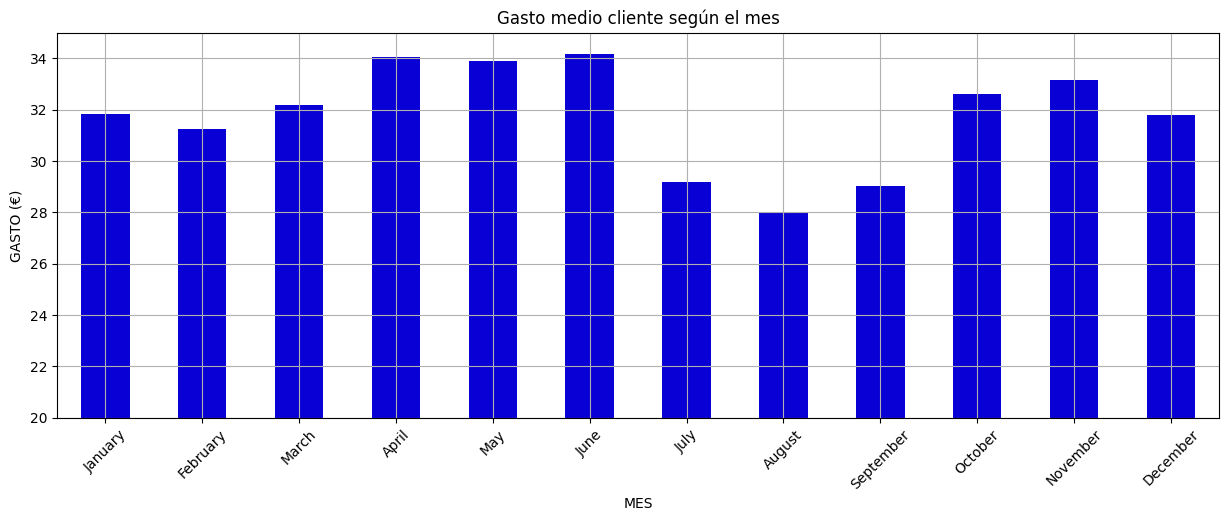

In [64]:
# llamo a pyplot para genrerar gráficas
from matplotlib import pyplot as plt
# Asigno parámetros al gráfico
gasto_medio_mes.plot(kind = 'bar',
                    x = 'Month',
                     y = 'money',
                    xlabel = 'MES',
                    ylabel = 'GASTO (€)',
                    title = 'Gasto medio cliente según el mes',
                    figsize = [15,5],
                    ylim = [20,35],
                    style = 'o',
                    grid = True,
                    color = '#0800D4')
plt.xticks(
    ticks=range(len(gasto_medio_mes.index)),
    labels=gasto_medio_mes.index,
    rotation=45
)
plt.show()

- A través de ylim he decidido que el mes con el valor de 'money' más bajo aparezca aproximadamente en el medio.
- De está forma se puede generar una impresión ajustada sobre valores minimos y máximos.

In [47]:
# Gasto medio por hora
gasto_medio_hora = df.groupby('hour_of_day')['money'].mean()
print(gasto_medio_hora)

hour_of_day
6     29.880000
7     32.341136
8     29.863319
9     30.017686
10    31.093049
11    29.869611
12    30.786805
13    31.238933
14    31.883556
15    31.678051
16    32.488633
17    32.319662
18    32.855963
19    33.851354
20    33.011361
21    32.809949
22    32.169558
Name: money, dtype: float64


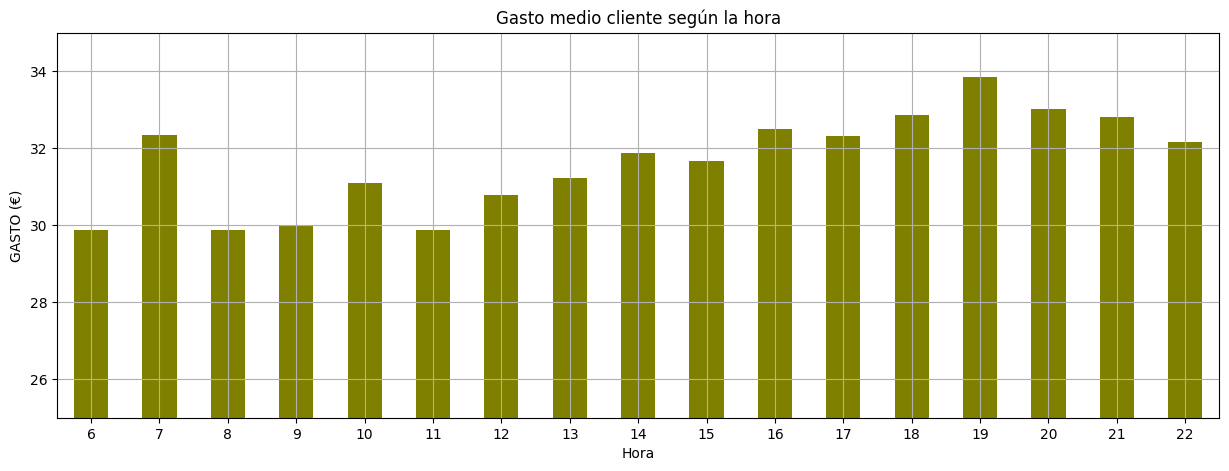

In [65]:
gasto_medio_hora.plot(kind = 'bar',
                    x = 'hour_of_day',
                     y = 'money',
                    xlabel = 'Hora',
                    ylabel = 'GASTO (€)',
                    title = 'Gasto medio cliente según la hora',
                    figsize = [15,5],
                    ylim = [25,35],
                    style = 'o',
                    grid = True ,
                    color = "olive")
plt.xticks(rotation = 0)
plt.show()

- Se pueden ver claramente las mejores horas de consumo pero sin mostrar discrepancias de los valores de forma artificial

0.20307705451357397


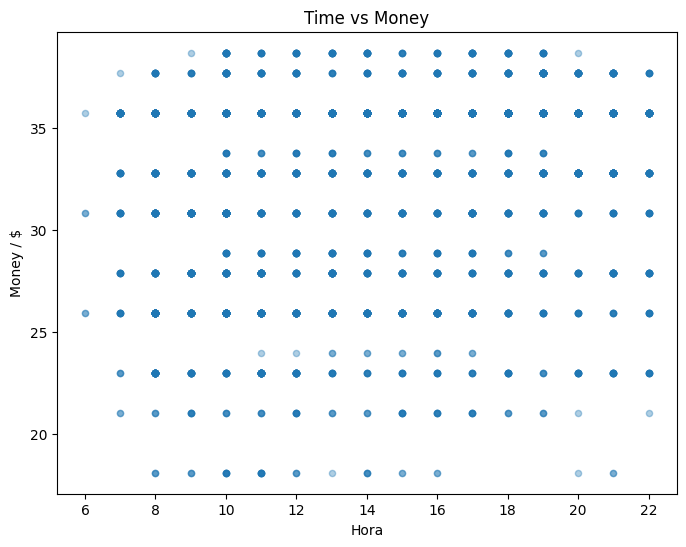

In [67]:
# Voy a crear una gráfica de dispersión para hour_of_day y money
df.plot(x = 'hour_of_day',
        y = 'money',
        kind = 'scatter',
        title = 'Time vs Money', 
        alpha = 0.36, 
        figsize = [8,6], 
        xlabel = 'Hora', 
        ylabel = 'Money / $')

print(df['Time'].corr(df['money']))

plt.show()

- Hay una ligera desviación positiva, refleja que el consumo aumenta segun avanza el día.

In [71]:
# Creo una nueva columna con el dato time en float para poderlo reflejar en un gráfico
df["hour_float"] = df["Time"].dt.total_seconds() / 3600
print(df['hour_float'])

0       10.264033
1       12.322927
2       12.338358
3       13.775835
4       13.804063
          ...    
3542    10.581915
3543    14.727045
3544    14.738018
3545    15.791312
3546    18.194065
Name: hour_float, Length: 3547, dtype: float64


0.20307705451357397


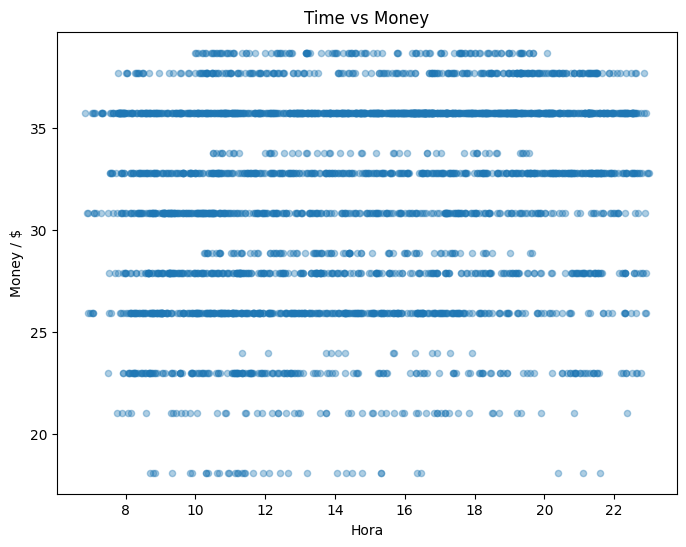

In [72]:
# Voy a crear una gráfica de dispersión para hour_float y money
df.plot(x = 'hour_float',
        y = 'money',
        kind = 'scatter',
        title = 'Time vs Money', 
        alpha = 0.36, 
        figsize = [8,6], 
        xlabel = 'Hora', 
        ylabel = 'Money / $')

print(df['hour_float'].corr(df['money']))

plt.show()

- Ahora la gráfica parece menos sintética al menos en el eje x, supongo que es normal que el gasto tenga importes repetidos.